In [1]:
!pip install --quiet opencv-python pywavelets mahotas scikit-image

import zipfile, os, glob, math, warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mahotas
import seaborn as sns

from scipy.stats import entropy
from skimage.color import rgb2gray
from skimage.exposure import rescale_intensity

from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 17.1 MB/s eta 0:00:00


In [2]:
print("Upload your ZIP file when prompted.")
uploaded = files.upload()

if len(uploaded) == 0:
    raise SystemExit("No file uploaded.")

zip_path = list(uploaded.keys())[0]
extract_path = "/content/lung_dataset"

if os.path.exists(extract_path):
    import shutil
    shutil.rmtree(extract_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete ->", extract_path)

Upload your ZIP file when prompted.


Saving Colon_1.zip to Colon_1.zip
Extraction complete -> /content/lung_dataset


In [3]:
image_files = []

for ext in ("png", "jpg", "jpeg", "tif", "tiff", "bmp"):
    image_files += glob.glob(
        os.path.join(extract_path, "**", f"*.{ext}"),
        recursive=True
    )

image_files = sorted(image_files)

print("Total images found:", len(image_files))

if len(image_files) == 0:
    raise SystemExit("No images found in the extracted archive.")


Total images found: 4000


In [4]:
def preprocess_image(path, size=128):
    img_bgr = cv2.imread(path)

    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    img_rgb = cv2.resize(
        img_rgb,
        (size, size),
        interpolation=cv2.INTER_LINEAR
    )

    gray = rgb2gray(img_rgb)

    gray_u8 = rescale_intensity(
        gray,
        out_range=(0, 255)
    ).astype(np.uint8)

    return img_rgb, gray_u8

def haralick_feats(gray_u8):
    feats = mahotas.features.haralick(gray_u8).mean(axis=0)
    return feats.astype(float)

def fft_features(gray_u8, n_bins=32):
    arr = gray_u8.astype(np.float32)

    fft = np.fft.fft2(arr)
    fft_shifted = np.fft.fftshift(fft)

    mag = np.abs(fft_shifted)
    S = np.log1p(mag)

    cy, cx = np.array(S.shape) // 2
    y, x = np.indices(S.shape)

    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    r = r.astype(np.int32)

    numer = np.bincount(r.ravel(), S.ravel())
    denom = np.bincount(r.ravel())

    radial = numer / (denom + 1e-12)

    bins = np.linspace(0, len(radial), n_bins + 1, dtype=int)

    rfft = []

    for i in range(n_bins):
        s, e = bins[i], bins[i + 1]

        if e > s:
            rfft.append(float(np.mean(radial[s:e])))
        else:
            rfft.append(0.0)

    rfft = np.array(rfft, dtype=float)

    # Normalize RFFT to unit sum
    rfft = rfft / (np.sum(rfft) + 1e-12)

    sfft = np.array([
        np.mean(S),
        np.std(S),
        np.max(S),
        np.sum(S ** 2)
    ], dtype=float)

    return rfft, sfft

def fractal_global(gray_u8, threshold=None):
    if threshold is None:
        threshold = int(np.median(gray_u8))

    Z = gray_u8 < threshold

    min_dim = min(Z.shape)
    max_power = int(math.floor(math.log(min_dim, 2)))

    sizes = 2 ** np.arange(1, max_power + 1)

    counts = []

    for s in sizes:
        ny = math.ceil(Z.shape[0] / s)
        nx = math.ceil(Z.shape[1] / s)

        cnt = 0

        for iy in range(ny):
            for ix in range(nx):
                patch = Z[iy*s:(iy+1)*s, ix*s:(ix+1)*s]

                if patch.size > 0 and patch.any():
                    cnt += 1

        counts.append(cnt if cnt > 0 else 1)

    x = np.log(1.0 / sizes)
    y = np.log(np.array(counts))

    try:
        D, _ = np.polyfit(x, y, 1)
    except:
        D = 0.0

    return float(D)

def fractal_local_values(gray_u8, grid=8):
    h, w = gray_u8.shape

    ph = h // grid
    pw = w // grid

    vals = []

    for i in range(grid):
        for j in range(grid):
            patch = gray_u8[
                i*ph:(i+1)*ph,
                j*pw:(j+1)*pw
            ]

            try:
                D = fractal_global(patch)

                if np.isnan(D):
                    D = 0.0

            except:
                D = 0.0

            vals.append(float(D))

    return np.array(vals, dtype=float)

def grayscale_stats(gray_u8):
    mean_val = np.mean(gray_u8)
    std_val = np.std(gray_u8)

    hist, _ = np.histogram(
        gray_u8,
        bins=256,
        range=(0, 255),
        density=True
    )

    ent_val = entropy(hist + 1e-12, base=2)

    return np.array([
        mean_val,
        std_val,
        ent_val
    ], dtype=float)




In [5]:
def extract_features(path):
    img_rgb, gray = preprocess_image(path, size=128)

    h_feats = haralick_feats(gray)                 # 13
    fd_global = np.array([fractal_global(gray)])   # 1
    fd_local = fractal_local_values(gray, 8)       # 64
    rfft, sfft = fft_features(gray, 32)            # 32 + 4
    gray_stat = grayscale_stats(gray)              # 3

    feat = np.concatenate([
        h_feats,
        fd_global,
        fd_local,
        rfft,
        sfft,
        gray_stat
    ])

    feat = np.nan_to_num(
        feat,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return feat


Sample image: /content/lung_dataset/Colon_1/colon_aca/colonca1089.jpeg


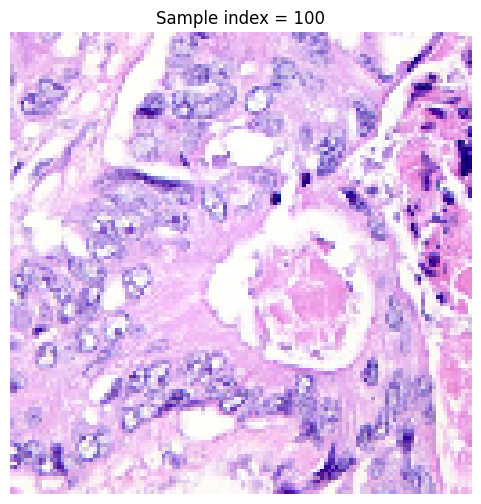

Feature vector length: 117
First 20 feature values:
[ 3.46098682e-04  1.29772563e+03  6.25323469e-01  1.73233181e+03
  8.23238808e-02  3.92988053e+02  5.63160159e+03  8.00103672e+00
  1.29862884e+01  6.96776062e-05  6.05052375e+00 -1.68651449e-01
  9.52437471e-01  1.94365402e+00  1.88441295e+00  1.86617781e+00
  1.77730957e+00  1.90172760e+00  1.90172760e+00  1.86617781e+00]


In [6]:
index = 100
index = min(index, len(image_files) - 1)

sample_path = image_files[index]

print("Sample image:", sample_path)

img_rgb, img_gray = preprocess_image(sample_path, size=128)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Sample index = {index}")
plt.show()

fv = extract_features(sample_path)

print("Feature vector length:", fv.shape[0])
print("First 20 feature values:")
print(fv[:20])

In [7]:
print("Extracting features for all images...")

X = []
y = []
failed = 0

for p in image_files:
    try:
        feats = extract_features(p)
        X.append(feats)

        parent = Path(p).parent.name.lower()

        label = 1 if (
            "lung_aca" in parent or
            "aca" in parent or
            "cancer" in parent or
            "tumor" in parent
        ) else 0

        y.append(label)

    except Exception as e:
        failed += 1
        print("Feature extraction failed for:", p, "->", e)

print("Done.")
print("Features extracted:", len(X))
print("Failed:", failed)

if len(X) == 0:
    raise SystemExit("No features extracted.")

X = np.vstack(X)
y = np.array(y, dtype=int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive labels:", int(y.sum()))
print("Negative labels:", int(len(y) - y.sum()))

Extracting features for all images...
Done.
Features extracted: 4000
Failed: 0
X shape: (4000, 117)
y shape: (4000,)
Positive labels: 2000
Negative labels: 2000


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3200, 117)
Test size: (800, 117)


In [9]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_svm = grid.best_estimator_

y_pred = best_svm.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Cancer"]
))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)



Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'svm__C': 10, 'svm__gamma': 'scale'}
Best CV Score: 0.9528085527775693
Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       400
      Cancer       0.99      0.97      0.98       400

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800

Confusion Matrix:
[[396   4]
 [ 12 388]]


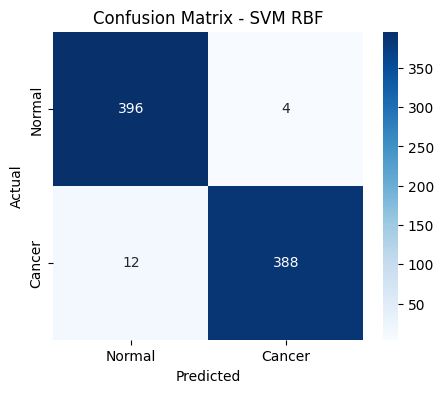

In [10]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Cancer"],
    yticklabels=["Normal", "Cancer"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM RBF")
plt.show()

ROC AUC Score - SVM RBF: 0.9974


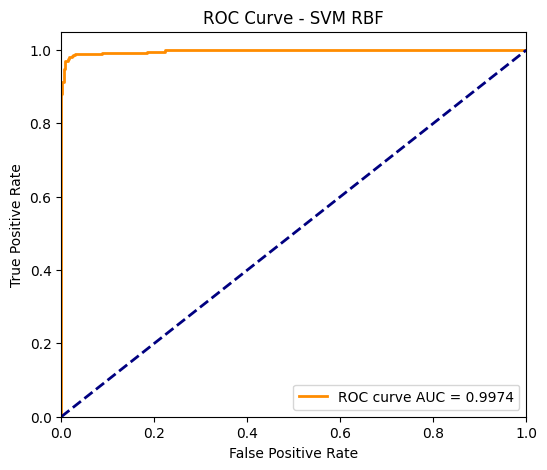

In [11]:
y_prob = best_svm.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC Score - SVM RBF: {roc_auc:.4f}")

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC curve AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=2,
    linestyle="--"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM RBF")
plt.legend(loc="lower right")
plt.show()

In [12]:
cols = []

cols += [f"haralick_{i}" for i in range(13)]
cols += ["fd_global"]
cols += [f"fd_local_{i}" for i in range(64)]
cols += [f"rfft_{i}" for i in range(32)]
cols += ["sfft_mean", "sfft_std", "sfft_max", "sfft_energy"]
cols += ["gray_mean", "gray_std", "gray_entropy"]

df = pd.DataFrame(X, columns=cols)
df["label"] = y

out_csv = "/content/extracted_features_117_SVM.csv"

df.to_csv(out_csv, index=False)

print("Saved features to:", out_csv)


Saved features to: /content/extracted_features_117_SVM.csv


In [13]:
files.download(out_csv)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>